In [57]:
import numpy as np
import matplotlib.pyplot as plt

1
Nutze: Definiert eine funktion namens formel die dafür da ist ein einzelnes neuron auszuführen mit relu
       es gibt 4 parameter
            1. Der eingabe wert fürs neuron
            2. Der multiplikator multipliziert den wert mit sich selbst
            3. Der bias der einen Konstanten wert hinzufügt zu dem ergbniss der rechnung von Punkt 2
            4. Relu ist dafür da wie viel größer ein bestimmter wert zum zurück geben sein muss 

In [58]:
def formel(wert,multiplier,bias,relu):
    x = wert*multiplier+bias
    if x >=relu:
        return x
    else:
        return 0

2
Nutze: Generriert ein Netz 
    es gibt 2 eingabewerte:
        1. Neuronenanz wie viele neuronen in welcher schicht sein sollen
        2. Parameteranz wie viele parameter ein neuron hat
    Funktionsweise: multipliziert die anzahl an schichten mit der anzahl summe aus der neuronen anzahl liste und den parametern
                    und gibt eine 1d matritze nur mit einsen zurück. Die anzahl der einsen entspricht der formel  

In [59]:
def genneuronen( neuronenanz, parameteranz):
    schichtenanz =len(neuronenanz)
    return np.ones((schichtenanz*sum(neuronenanz)*parameteranz))

3
Nutze: Führt das Netz aus mit den gegebenen eingabe werten.

         Es gibt 4 Parameter:
            1. Werte enthält die eingabe werte
            2. Netz enthält das Netz 
            3. Neuronenanz enthält die anzahl an neuronen in welche schicht sind damit die funktion der 1d matritze (Das netz) in 
               2d aufteilen kann 
            *4. Schichtanz enthält die anzahl an schichten
         Funktionsweise: Es geht die schichten durch in jeder schicht geht sie die neuronen durch und währenddessen geht es die ergebnisse der vorschicht durch gibt
                         sie an die neuronen die sie durch geht und addiert die ergebnisse fügt am ende wenn es alle werte durch gegangen ist der vorschicht
                         in eine liste hinzu löscht die aktuelle werte liste und aktualisiert sie mit den neuen werten



In [60]:
def run(werte,netz,neuronenanz):
    schichtanz =np.size(neuronenanz)
    print(f"schichtanz: {schichtanz}")
    print(f"Netz in run: {netz}")
    """
    print("run:"+str(netz))
    """
    cord = 0
    for i in range(schichtanz):
        adder = 0
        tempwert = np.array([])
        for x in range(neuronenanz[i]):
            
            for s in range(np.size(werte)):
                    if sum(neuronenanz)!=cord: 
                        print(cord*3)
                        print(cord*3+1)
                        print(cord*3+2)
                        adder +=  formel(werte[s],netz[(cord*3)],netz[(cord*3+1)],netz[(cord*3+2)])
                        
                
                        
                        
                        
                        cord += 1
                    print(f"Cord: {x}")
            tempwert = np.append(tempwert,adder)
            adder = 0
        print(werte)  
        werte = tempwert
        print(werte)
    return tempwert

In [61]:
print(run(np.array([4]),genneuronen(np.array([1,3]),3),np.array([1,3])))

schichtanz: 2
Netz in run: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
0
1
2
Cord: 0
[4]
[5.]
3
4
5
Cord: 0
6
7
8
Cord: 1
9
10
11
Cord: 2
[5.]
[6. 6. 6.]
[6. 6. 6.]


Nutze: Berrechnet den Fehler wert
         Es gibt 2 Parameter:
            1. Expectedvalue enthält den wert was das das ergbniss der rechnung sein muss
            2. Calcedvalue enthält den wert der Mit dem netz berrechnet wurde

In [62]:
def fehlerwert(expectedvalue,calcedvalue):
    return (sum(expectedvalue)/sum(calcedvalue))-1

Nutze: Berrechnet den fehlerwert für eine liste an eingabe werte mit den bekannten ausgabewerten und gibt den Durchschnit zurück

In [63]:
def error(netz,eingabewerte,ausgabewerte,neuronenanz):
    schichtanz =len(neuronenanz)
    """
    print("error:"+str(netz))
    """
    errorvalue = np.array([])
    
    for x in range(len(eingabewerte)):
        calcedvalue = run(eingabewerte[x],netz,neuronenanz)
        errorvalue = np.append(errorvalue,fehlerwert(calcedvalue,ausgabewerte[x]))


    return sum(errorvalue)/len(errorvalue)

Nutze: Berrechnet den fehlerwert für das gegebene netz und optimiert jedes neuron testweise und berrechnet den fehler wert für das modfizierte Netz und gibt die beste
       mutation zurück wenn sei besser als der aktuelle ist.


       Es gibt 6 eingabewerte:
            1.  Netz das Neuronale netz
            2.  Counttrainval 
            3.  Eingabewert
            4.  Ausgabewert
            5.  Learningrate
            6.  Neuronenanz

          Funktion:
            

In [64]:

def thebest(netz,eingabewert,ausgabewert,learningrate,neuronenanz):
    schichtanz =len(neuronenanz)
    changednetz = netz
    errornp = np.array([])

    temperror1 = np.array([])
    temperror2 = np.array([])
    
    smalest = np.array([],dtype=np.int16)
    for i in range(np.size(netz,)):
        
        for x in range(2):
            changednetz = netz
            if x == 0:
                changednetz[i] += learningrate
                temperror1 = error(netz,eingabewert,ausgabewert,neuronenanz)
                    
            else:
                changednetz[i] -= learningrate
                temperror2 = error(netz,eingabewert,ausgabewert,neuronenanz)
        """
        print("Temperror1:"+str(temperror1))
        print("Temperror2:"+str(temperror2))
        """
        errornp = np.append(errornp,temperror1)
        errornp = np.append(errornp,temperror2)
        temperror1 = np.array([])
        temperror2 = np.array([])
    for i in range(len(errornp)):
        if i ==0:
            smalest = np.append(smalest,0)
        elif errornp[i] < errornp[np.size(smalest)]:
            smalest = np.append(smalest,i)


    """
    print("Netz : "+str(netz))
    print("SMallst: "+str(smalest))
    """
    if smalest[-1] %2 ==0:
        netz[(smalest[-1]//2)] +=learningrate
        return netz
    else:
        netz[(smalest[-1]//2)-1] -=learningrate
        return netz



   

In [65]:
def optimize(netz,eingabewerte,ausgabewerte,neuronenanz,netzcount,cycle,learningrate):
    schichtanz =len(neuronenanz)
    #generriert multinetz
    multinetz = np.array([netz])
    for i in range(netzcount):
        if i== 0:
            pass
        else:
            
            
            mininetz = np.random.rand(np.size(netz))
            multinetz = np.vstack((multinetz,mininetz))
            """
            print(multinetz[i])
            print(multinetz)
            """
    print("Multinetz: "+str(multinetz))
    for s in range(cycle):
        for i in range(netzcount):
            """
            print("Multinetz: " + str(multinetz))
            print("Multinetz[i]: " + str(multinetz[i]))
            print(multinetz)
            """
            temp = thebest(multinetz[i],eingabewerte,ausgabewerte,learningrate,neuronenanz)
            """print("Temp: "+str(temp))"""
            multinetz[i] = temp
            
            
    return multinetz

    

Test

Multinetz: [[1.         1.         1.         1.         1.         1.
  1.         1.         1.        ]
 [0.22746271 0.43499141 0.83937706 0.11858499 0.8065602  0.18018489
  0.24169852 0.68193486 0.60012471]
 [0.68370829 0.95913106 0.9531028  0.05619315 0.36883262 0.31519969
  0.24594466 0.5846301  0.10756091]]
schichtanz: 2
Netz in run: [1.2 1.  1.  1.  1.  1.  1.  1.  1. ]
0
1
2
Cord: 0
3
4
5
Cord: 0
6
7
8
Cord: 1
Cord: 1
[0 1]
[3. 1.]
Cord: 0
Cord: 0
[3. 1.]
[0.]
schichtanz: 2
Netz in run: [1.2 1.  1.  1.  1.  1.  1.  1.  1. ]
0
1
2
Cord: 0
3
4
5
Cord: 0
6
7
8
Cord: 1
Cord: 1
[1 0]
[3.2 2. ]
Cord: 0
Cord: 0
[3.2 2. ]
[0.]
schichtanz: 2
Netz in run: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
0
1
2
Cord: 0
3
4
5
Cord: 0
6
7
8
Cord: 1
Cord: 1
[0 1]
[3. 1.]
Cord: 0
Cord: 0
[3. 1.]
[0.]
schichtanz: 2
Netz in run: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
0
1
2
Cord: 0
3
4
5
Cord: 0
6
7
8
Cord: 1
Cord: 1
[1 0]
[3. 2.]
Cord: 0
Cord: 0
[3. 2.]
[0.]
schichtanz: 2
Netz in run: [1.  1.2 1.  1.  1.  1.  1.  1.  1. ]
0

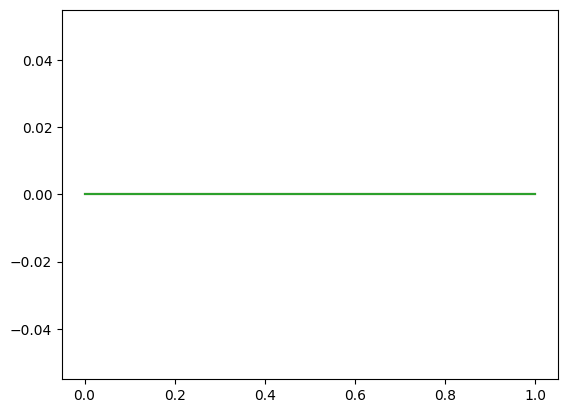

In [66]:
netz = np.array([1,1,1,1,1,1,1,1,1])
eingabewerte = np.array([[0,1],[1,0]])
ausgabewerte = np.array([[1],[1]])
neuronenanz = np.array([2,1])
netzcount = 3
cycle = 100
learningrate = 0.2
netze = optimize(netz,eingabewerte,ausgabewerte,neuronenanz,netzcount,cycle,learningrate)
print("Netze: "+str(netze))
ausgabe = np.array([run(np.array([0,1]),netze[1],neuronenanz),run(np.array([1,0]),netze[1],neuronenanz)])
plt.plot(ausgabe)
plt.plot(np.array([run(np.array([0,1]),netze[0],neuronenanz),run(np.array([1,0]),netze[0],neuronenanz)]))
plt.plot(np.array([run(np.array([0,1]),netze[2],neuronenanz),run(np.array([1,0]),netze[2],neuronenanz)]))

plt.show()


In [67]:
#note der fehler bedeutet am ende das der code versucht eine 1d matritze um eine 1d zu erweitern oder so

x = np.array([[32,3,3]])

x = np.vstack((x, np.array([[32,3,3]])))

print(x)
print(np.array([run(np.array([0,1]),netze[0],neuronenanz),run(np.array([1,0]),netze[0],neuronenanz)]))
print(np.array([run(np.array([0,1]),netze[1],neuronenanz),run(np.array([1,0]),netze[1],neuronenanz)]))
print(np.array([run(np.array([0,1]),netze[2],neuronenanz),run(np.array([1,0]),netze[2],neuronenanz)]))

[[32  3  3]
 [32  3  3]]
schichtanz: 2
Netz in run: [21.  1.  1.  1.  1.  1.  1.  1.  1.]
0
1
2
Cord: 0
3
4
5
Cord: 0
6
7
8
Cord: 1
Cord: 1
[0 1]
[3. 1.]
Cord: 0
Cord: 0
[3. 1.]
[0.]
schichtanz: 2
Netz in run: [21.  1.  1.  1.  1.  1.  1.  1.  1.]
0
1
2
Cord: 0
3
4
5
Cord: 0
6
7
8
Cord: 1
Cord: 1
[1 0]
[23.  2.]
Cord: 0
Cord: 0
[23.  2.]
[0.]
[[0.]
 [0.]]
schichtanz: 2
Netz in run: [20.22746271  0.43499141  0.83937706  0.11858499  0.8065602   0.18018489
  0.24169852  0.68193486  0.60012471]
0
1
2
Cord: 0
3
4
5
Cord: 0
6
7
8
Cord: 1
Cord: 1
[0 1]
[0.92514519 0.68193486]
Cord: 0
Cord: 0
[0.92514519 0.68193486]
[0.]
schichtanz: 2
Netz in run: [20.22746271  0.43499141  0.83937706  0.11858499  0.8065602   0.18018489
  0.24169852  0.68193486  0.60012471]
0
1
2
Cord: 0
3
4
5
Cord: 0
6
7
8
Cord: 1
Cord: 1
[1 0]
[21.46901432  0.92363338]
Cord: 0
Cord: 0
[21.46901432  0.92363338]
[0.]
[[0.]
 [0.]]
schichtanz: 2
Netz in run: [20.68370829  0.95913106  0.9531028   0.05619315  0.36883262  0.31519969